In [1]:
%matplotlib inline
import pandas as pd
import lightkurve as lk
import astropy.units as u
import matplotlib.pyplot as plt
import numpy as np

df = pd.read_csv("tess_id_sector_exptime_G16d20_all_filtered_UPDATED.csv")

first_id = int(df["ID"].dropna().iloc[0])
print("First target:", first_id)

# show the rows for this target (FFI + SPOC)
display(df[df["ID"] == first_id])


First target: 769456276704128


,ID,DataType,Sector,Exposure_Time,FFI_Avail,SPOC_Avail
0,769456276704128,FFI,4.0,1425.599419,True,True
1,769456276704128,FFI,31.0,475.19979,True,True
2,769456276704128,SPOC,NaN,[120.] s,True,True
3,769456276704128,SPOC,NaN,[120.] s,True,True


In [ ]:
target = f"Gaia DR3 769456276704128"

sr_lc = lk.search_lightcurve(target, mission="TESS", author="SPOC")  
print(sr_lc)

lcc = sr_lc.download_all()
lc = lcc.stitch()
lc


SearchResult containing 2 data products.

 #     mission     year author exptime target_name distance
                                  s                 arcsec 
--- -------------- ---- ------ ------- ----------- --------
  0 TESS Sector 04 2018   SPOC     120   328401671      0.0
  1 TESS Sector 31 2020   SPOC     120   328401671      0.0


time,flux,flux_err,timecorr,cadenceno,centroid_col,centroid_row,sap_flux,sap_flux_err,sap_bkg,sap_bkg_err,pdcsap_flux,pdcsap_flux_err,quality,psf_centr1,psf_centr1_err,psf_centr2,psf_centr2_err,mom_centr1,mom_centr1_err,mom_centr2,mom_centr2_err,pos_corr1,pos_corr2
,,,d,,pix,pix,electron / s,electron / s,electron / s,electron / s,electron / s,electron / s,,pix,pix,pix,pix,pix,pix,pix,pix,pix,pix
Time,float32,float32,float32,int32,float64,float64,float32,float32,float32,float32,float32,float32,int32,float64,float32,float64,float32,float64,float32,float64,float32,float32,float32
1410.9078867947098,1.0068877e+00,7.8319367e-03,5.2594487e-03,132082,924.74270,1539.61882,6.0974213e+02,4.7450213e+00,8.0415900e+02,2.1866493e+00,8.5420343e+02,6.6443033e+00,0,———,———,———,———,924.74270,5.4820799e-03,1539.61882,3.5525395e-03,-1.5363242e-01,1.6808777e-01
1410.9092757351864,9.9502957e-01,7.8186598e-03,5.2595008e-03,132083,924.75163,1539.61634,6.0235199e+02,4.7369776e+00,8.0375781e+02,2.1816852e+00,8.4414349e+02,6.6330400e+00,0,———,———,———,———,924.75163,5.5424585e-03,1539.61634,3.5899314e-03,-1.5262674e-01,1.6838431e-01
1410.910664675663,9.9526793e-01,7.8098332e-03,5.2595530e-03,132084,924.74935,1539.61727,6.0294055e+02,4.7316294e+00,8.0139893e+02,2.1805947e+00,8.4434570e+02,6.6255517e+00,0,———,———,———,———,924.74935,5.5209533e-03,1539.61727,3.5818091e-03,-1.5173505e-01,1.6520785e-01
1410.9120536166045,9.8993838e-01,7.8222556e-03,5.2596056e-03,132085,924.73400,1539.61561,5.9930658e+02,4.7391558e+00,8.0802612e+02,2.1894178e+00,8.3982434e+02,6.6360903e+00,0,———,———,———,———,924.73400,5.5717332e-03,1539.61561,3.6074209e-03,-1.5516743e-01,1.6842282e-01
1410.9134425570803,9.8616952e-01,7.8099868e-03,5.2596577e-03,132086,924.74915,1539.61454,5.9723132e+02,4.7317228e+00,8.0459595e+02,2.1822090e+00,8.3662701e+02,6.6256824e+00,0,———,———,———,———,924.74915,5.5726445e-03,1539.61454,3.6152056e-03,-1.5225431e-01,1.6406392e-01
1410.9148314975569,1.0055159e+00,7.8264531e-03,5.2597099e-03,132087,924.75063,1539.61317,6.0963397e+02,4.7416987e+00,8.0329016e+02,2.1792562e+00,8.5303973e+02,6.6396513e+00,0,———,———,———,———,924.75063,5.4647536e-03,1539.61317,3.5502554e-03,-1.4882642e-01,1.6000381e-01
1410.9162204380334,1.0067637e+00,7.8397170e-03,5.2597621e-03,132088,924.75145,1539.61808,6.0970032e+02,4.7497344e+00,8.0391461e+02,2.1866467e+00,8.5409827e+02,6.6509037e+00,0,———,———,———,———,924.75145,5.4649548e-03,1539.61808,3.5569258e-03,-1.5506613e-01,1.6860464e-01
1410.9176093785093,1.0077536e+00,7.8290151e-03,5.2598142e-03,132089,924.75620,1539.61349,6.1045959e+02,4.7432508e+00,8.0417950e+02,2.1816566e+00,8.5493811e+02,6.6418247e+00,0,———,———,———,———,924.75620,5.4604178e-03,1539.61349,3.5460941e-03,-1.5280442e-01,1.6432157e-01


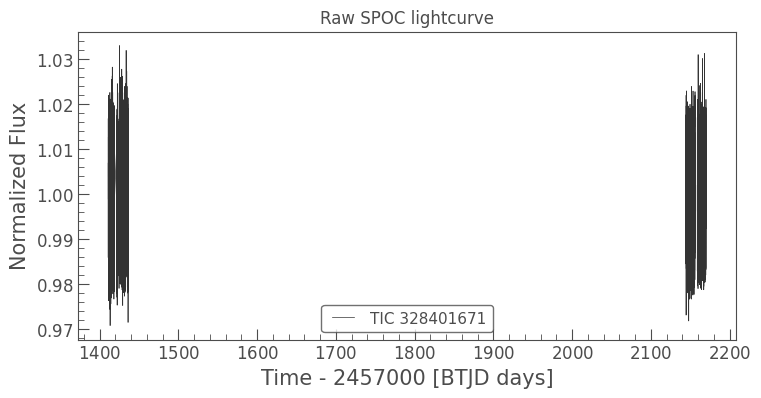

In [4]:
lc.plot()
plt.title("Raw SPOC lightcurve")
plt.show()


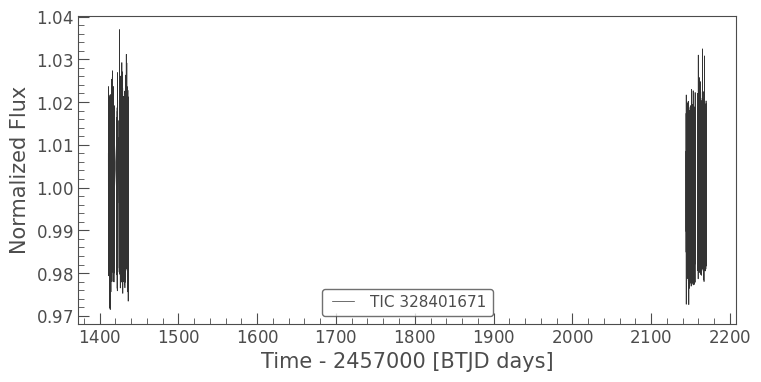

In [6]:
lc_flat = lc.flatten(101)
lc_flat.plot()
plt.show()


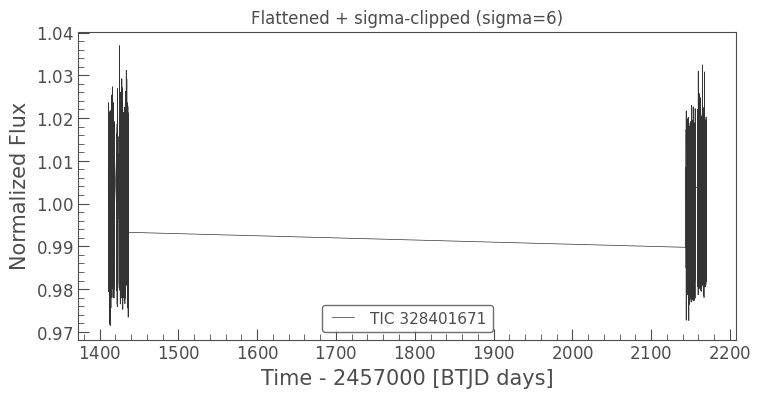

In [ ]:
lc_clip = lc_flat.remove_outliers(sigma=6)
lc_clip.plot()
plt.show()


In [9]:
cdpp_native = lc_clip.estimate_cdpp()
#print("CDPP (native cadence):", cdpp_native, "  =", cdpp_native.to_value(u.ppm), "ppm")


In [10]:
binned_10m = lc_clip.bin(time_bin_size=10*u.minute)

cdpp_10m = binned_10m.estimate_cdpp()
print("CDPP (binned to 10 min):", cdpp_10m, "  =", cdpp_10m.to_value(u.ppm), "ppm")

ratio_10m = cdpp_10m.to_value(u.ppm) / cdpp_native.to_value(u.ppm)
print("Ratio (10 min / native):", ratio_10m)

binned_10m.plot()
plt.title("Binned to 10 minutes")
plt.show()


AttributeError: module 'astropy.units' has no attribute 'ppm'